# 07 Professional Workflow with statsmodels

By the end of this notebook, you should be able to:

- decide when to use the course teaching functions and when to use a standard package;
- fit simple exponential smoothing, Holt's method, and Holt-Winters models with `statsmodels`;
- compare package output with the lecture-style recursive calculations;
- explain why different software may produce slightly different constants or forecasts.


## The Two Tracks

This module now has two complementary tracks.

| Track | Main purpose | What you should learn |
|---|---|---|
| Teaching track | Use `smoothing_utils.py` to expose the recursions from lecture and reproduce homework-style calculations | how the level, trend, seasonal factors, SSE optimization, and course prediction intervals are built |
| Professional track | Use `statsmodels` for the model fitting you would normally use in applied Python work | how to call a tested package, inspect fitted values and parameters, compare model families, and report forecasts |

For homework questions that explicitly ask for the course recursion table or the lecture prediction interval formula, use the teaching track. For a real analysis project, start with `statsmodels` unless you have a specific reason to implement the recursions yourself.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

from smoothing_utils import (
    accuracy_measures,
    initial_level_mean,
    initial_line,
    optimize_simple_es,
    optimize_holt,
    holt_forecast_table,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)
DATA_DIR = Path('data')


def metrics_from_fitted(actual, fitted):
    return pd.Series(accuracy_measures(actual, fitted), name='value')


def smoothing_params(result):
    keep = ['smoothing_level', 'smoothing_trend', 'smoothing_seasonal']
    return pd.Series({key: result.params.get(key, np.nan) for key in keep}, name='value')

## Simple Exponential Smoothing

The lecture calculation is useful because it shows exactly what `alpha` does. In applied work, the same model can be fit with `SimpleExpSmoothing`.

Here we provide the same initial level used in lecture so the package result lines up with the teaching recursion. If you let the package estimate initialization by itself, the fitted constants may be slightly different.


In [3]:
cod = pd.read_csv(DATA_DIR / 'cod_catch.csv')
y_cod = cod['CodCatch'].to_numpy()
l0_cod = initial_level_mean(y_cod, n=12)

alpha_teach, fit_teach, metrics_teach = optimize_simple_es(y_cod, l0=l0_cod)
ses_sm = SimpleExpSmoothing(
    y_cod,
    initialization_method='known',
    initial_level=l0_cod,
).fit(optimized=True)

comparison = pd.DataFrame({
    'teaching_track': {
        'alpha': alpha_teach,
        'SSE': metrics_teach['SSE'],
        'next_forecast': fit_teach['level'].iloc[-1],
    },
    'statsmodels_track': {
        'alpha': ses_sm.params['smoothing_level'],
        'SSE': accuracy_measures(y_cod, ses_sm.fittedvalues)['SSE'],
        'next_forecast': ses_sm.forecast(1)[0],
    },
})
comparison

,teaching_track,statsmodels_track
alpha,0.0344,0.0344
SSE,28089.1409,28089.1409
next_forecast,354.5438,354.5438


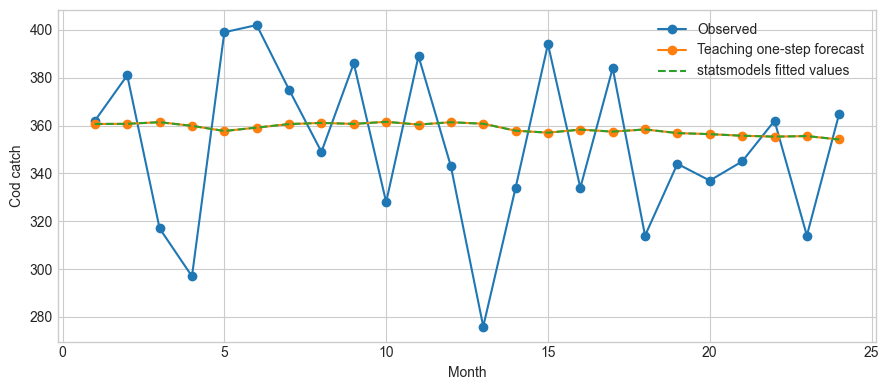

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cod['Time'], y_cod, marker='o', label='Observed')
ax.plot(cod['Time'], fit_teach['yhat_one_step'], marker='o', label='Teaching one-step forecast')
ax.plot(cod['Time'], ses_sm.fittedvalues, linestyle='--', label='statsmodels fitted values')
ax.set_xlabel('Month')
ax.set_ylabel('Cod catch')
ax.legend()
plt.tight_layout()

## Holt's Trend-Corrected Method

For a trend series, the professional package call is `Holt`. Again, we pass the lecture initial level and trend so the result is directly comparable with the recursive table from the teaching track.


In [5]:
therm = pd.read_csv(DATA_DIR / 'thermostat_sales.csv')
y_therm = therm['ThermostatSales'].to_numpy()
l0_therm, b0_therm = initial_line(y_therm, n=26)

alpha_h, gamma_h, fit_h_teach, metrics_h_teach = optimize_holt(y_therm, l0=l0_therm, b0=b0_therm)
holt_sm = Holt(
    y_therm,
    initialization_method='known',
    initial_level=l0_therm,
    initial_trend=b0_therm,
).fit(optimized=True)

pd.DataFrame({
    'teaching_track': {
        'alpha': alpha_h,
        'gamma': gamma_h,
        'SSE': metrics_h_teach['SSE'],
    },
    'statsmodels_track': {
        'alpha': holt_sm.params['smoothing_level'],
        'gamma': holt_sm.params['smoothing_trend'],
        'SSE': accuracy_measures(y_therm, holt_sm.fittedvalues)['SSE'],
    },
})

,teaching_track,statsmodels_track
alpha,0.2468,0.2468
gamma,0.0951,0.0951
SSE,38884.2448,38884.2448


In [6]:
course_holt_forecast = holt_forecast_table(fit_h_teach, alpha=alpha_h, gamma=gamma_h, h=6)
professional_holt_forecast = pd.DataFrame({
    'tau': range(1, 7),
    'statsmodels_point_forecast': holt_sm.forecast(6),
})

course_holt_forecast.merge(professional_holt_forecast, on='tau').round(2)

,tau,forecast,lower_95_PI,upper_95_PI,statsmodels_point_forecast
0,1,320.45,265.79,375.11,320.45
1,2,324.95,268.33,381.57,324.95
2,3,329.46,270.61,388.31,329.46
3,4,333.96,272.61,395.32,333.96
4,5,338.47,274.35,402.58,338.47
5,6,342.97,275.84,410.11,342.97


The teaching table includes the approximate 95% prediction intervals used in this course. The classic `statsmodels.tsa.holtwinters` results object gives point forecasts; interval reporting requires an additional modeling choice, such as a residual bootstrap, a separately justified error model, or a state-space ETS approach.


## Holt-Winters Seasonality

For seasonal data, the professional package call is `ExponentialSmoothing`. Use:

- `trend='add'` for a linear trend component;
- `seasonal='add'` when seasonal swings are roughly constant;
- `seasonal='mul'` when seasonal swings scale with the level;
- `seasonal_periods=4` for quarterly data, `12` for monthly data, and so on.


In [7]:
bike = pd.read_csv(DATA_DIR / 'bike_sales.csv')
y_bike = bike['BikeSales'].to_numpy()

hw_bike_add = ExponentialSmoothing(
    y_bike,
    trend='add',
    seasonal='add',
    seasonal_periods=4,
    initialization_method='estimated',
).fit(optimized=True)

print('Additive Holt-Winters smoothing parameters')
display(smoothing_params(hw_bike_add).to_frame())

pd.DataFrame({
    'tau': range(1, 5),
    'forecast': hw_bike_add.forecast(4),
}).round(2)

Additive Holt-Winters smoothing parameters


,value
smoothing_level,0.6387
smoothing_trend,0.0000
smoothing_seasonal,0.0000


,tau,forecast
0,1,22.30
1,2,44.05
2,3,57.05
3,4,28.55


In [8]:
drink = pd.read_csv(DATA_DIR / 'sports_drink_sales.csv')
y_drink = drink['DrinkSales'].to_numpy()

hw_drink_add = ExponentialSmoothing(
    y_drink,
    trend='add',
    seasonal='add',
    seasonal_periods=4,
    initialization_method='estimated',
).fit(optimized=True)

hw_drink_mul = ExponentialSmoothing(
    y_drink,
    trend='add',
    seasonal='mul',
    seasonal_periods=4,
    initialization_method='estimated',
).fit(optimized=True)

pd.DataFrame({
    'additive_HW': accuracy_measures(y_drink, hw_drink_add.fittedvalues),
    'multiplicative_HW': accuracy_measures(y_drink, hw_drink_mul.fittedvalues),
})

,additive_HW,multiplicative_HW
SSE,276.9643,98.9746
MAD,2.0067,1.3915
MSE,8.6551,3.0930
MAPE,1.5517,1.0805


,tau,additive_forecast,multiplicative_forecast
0,1,123.54,119.31
1,2,185.54,188.67
2,3,226.54,224.87
3,4,159.07,157.43


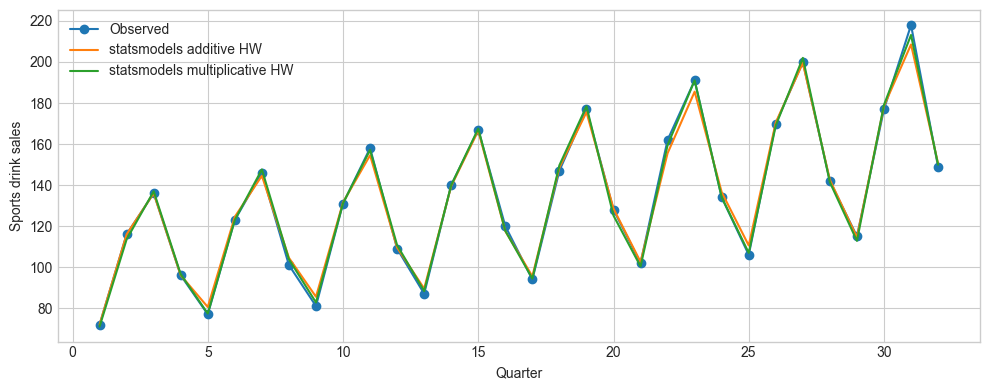

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(drink['Time'], y_drink, marker='o', label='Observed')
ax.plot(drink['Time'], hw_drink_add.fittedvalues, label='statsmodels additive HW')
ax.plot(drink['Time'], hw_drink_mul.fittedvalues, label='statsmodels multiplicative HW')
ax.set_xlabel('Quarter')
ax.set_ylabel('Sports drink sales')
ax.legend()
plt.tight_layout()

pd.DataFrame({
    'tau': range(1, 5),
    'additive_forecast': hw_drink_add.forecast(4),
    'multiplicative_forecast': hw_drink_mul.forecast(4),
}).round(2)

## Reusable Professional Template

This compact template is the kind of code you can adapt in a project. The modeling decision still comes from the plot and the business context; the package does not decide whether additive or multiplicative seasonality is conceptually appropriate for you.


In [10]:
def fit_statsmodels_smoothing(y, h, model_type='ses', seasonal_periods=None):
    if model_type == 'ses':
        model = SimpleExpSmoothing(y, initialization_method='estimated')
    elif model_type == 'holt':
        model = Holt(y, initialization_method='estimated')
    elif model_type == 'hw_add':
        model = ExponentialSmoothing(
            y,
            trend='add',
            seasonal='add',
            seasonal_periods=seasonal_periods,
            initialization_method='estimated',
        )
    elif model_type == 'hw_mul':
        model = ExponentialSmoothing(
            y,
            trend='add',
            seasonal='mul',
            seasonal_periods=seasonal_periods,
            initialization_method='estimated',
        )
    else:
        raise ValueError("model_type must be 'ses', 'holt', 'hw_add', or 'hw_mul'.")
    result = model.fit(optimized=True)
    fitted_metrics = accuracy_measures(y, result.fittedvalues)
    forecast = pd.DataFrame({'tau': range(1, h + 1), 'forecast': result.forecast(h)})
    return result, pd.Series(fitted_metrics).to_frame('value'), forecast

# Example: a quick professional Holt forecast for a non-homework trend series.
therm = pd.read_csv(DATA_DIR / 'thermostat_sales.csv')
therm_result, therm_metrics, therm_forecast = fit_statsmodels_smoothing(
    therm['ThermostatSales'].to_numpy(),
    h=6,
    model_type='holt',
)

therm_metrics.round(2), therm_forecast.round(2)


(         value
 SSE   38853.78
 MAD      21.73
 MSE     747.19
 MAPE      9.94,
    tau  forecast
 0    1    320.26
 1    2    324.73
 2    3    329.20
 3    4    333.67
 4    5    338.14
 5    6    342.61)

## Takeaways

Use the teaching track when you need to show or audit the exact recursion, reproduce a course spreadsheet, or apply a course-specific prediction interval formula.

Use the professional track when you are solving a real forecasting problem and want tested model-fitting code, standard parameter handling, and a workflow that transfers beyond this class.

Always report the model family, initialization/optimization choices when they matter, accuracy measures, forecast horizon, and any assumptions behind intervals. If two tools give slightly different constants, check whether they used the same initial states, objective function, and treatment of fitted values before calling one of them wrong.
